# Большое Домашнее Задание №1 : Кластеризация

В данном домашнем задании мы познакомимся поближе с кластеризацией.

Кластеризация — это метод машинного обучения, который включает группировку данных в пространстве признаков. Теоретически, точки, находящиеся в одной группе, должны иметь схожие свойства, в то время как точки в разных группах должны иметь сильно отличающиеся свойства.

Кластеризация является методом обучения без учителя и распространенным методом статистического анализа данных, используемым во многих областях. В частности используется при составлении портретов пользователей, поиске аномалий. В анализе данных часто прибегают к кластеризации, чтобы получить ценную информацию из наших данных, наблюдая, в какие группы попадают точки.

## Пишем K-means (3 балла)

В данном задании от вас потребуется реализовать алгоритм K-means самостоятельно. K-means принимает на вход вектора и присваивает им номер кластера. Напомним общий принцип работы алгоритма.

Для данного набора данных задается k - количество отдельных групп, к которым принадлежат точки. Эти k центроидов сначала инициализируются случайным образом, а затем выполняются итерации для оптимизации расположения этих k центроидов следующим образом:

1. Вычисляется расстояние от каждой точки до каждого центроида.
2. Точки приписываются к ближайшему центроиду.
3. Центроиды сдвигаются так, чтобы их среднее значение было равно среднему значению принадлежащих им точек. Если центроиды не сдвинулись, алгоритм завершается, в противном случае повторяется.



### Данные

Чтобы оценить наш алгоритм, мы сначала сгенерируем набор данных - группы в двумерном пространстве.
Функция sklearn.datasets [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) создает группы двумерных нормальных распределений и присваивает метку, соответствующую группе, к которой принадлежит точка.

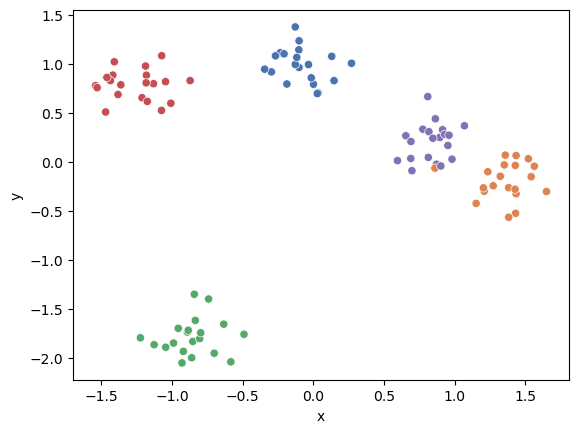

In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
centers = 5 # количество групп
X_train, true_labels = make_blobs(n_samples=100, centers=centers, random_state=42)
X_train = StandardScaler().fit_transform(X_train)
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=true_labels,
                palette="deep",
                legend=None
                )
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### А теперь пишем код

#### Вспомогательные функции

**Задание** В этом алгоритме нам нужно будет многократно вычислять расстояния между точкой и набором точек. Для этого определим функцию, которая вычисляет евклидовы расстояния.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean(point, data):
    """
    Euclidean distance between point & data.
    Point has dimensions (m,), data has dimensions (n,m), and output will be of size (n,).
    """
    # Все вычисления должны быть выполенны с помощью numpy без использования циклов
    result = np.sqrt(np.sum(np.power((data - point), 2), axis=1))
    return result

#### Алгоритм K-means

**Задание** Допишите код

In [3]:
from numpy.random import uniform

class KMeans:
    def __init__(self, n_clusters=8, max_iter=300):
        self.n_clusters = n_clusters # Количество кластеров
        self.max_iter = max_iter # Максимальное количество итераций

    def fit(self, X_train):
        """
        X_train: numpy array of shape (n,m)
        """
        # Случайно выбираем начальные точки центроида, равномерно распределенные по области набора данных

        # Найдите минимальное и максимальное значение для каждого измерения в X_train (координаты по широте и долготе) и сохраните их в min_ и max_
        
        min_ = (np.min(X_train[:, 0]), np.min(X_train[:, 1]))
        max_ = (np.max(X_train[:, 0]), np.max(X_train[:, 1]))
        self.centroids = [uniform(min_, max_) for _ in range(self.n_clusters)]

        # Итеративно повторяем до сходимости или до максимального количества итераций
        iteration = 0
        prev_centroids = None
        while np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:

            # Сортируем точки по ближайшему центроиду
            sorted_points = [[] for _ in range(self.n_clusters)]
            for x in X_train:
                dists = euclidean(x, self.centroids)
                #Найдите индекс ближайшего центроида см. функцию np.argmin
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)

            # Сохраните текущие центроиды в prev_centroids
            prev_centroids = self.centroids
            # Обновите центроиды средним значением точек в кластере
            tmp = []
            for i in sorted_points:
                tmp.append(np.mean(i, axis=0))
            self.centroids = tmp

            for i, centroid in enumerate(self.centroids):
                if np.isnan(centroid).any():  # Если центроид не имеет ни одной точки, то выбираем предыдущее значение
                    self.centroids[i] = prev_centroids[i]
            iteration += 1

    def evaluate(self, X):
        """
        Function to evaluate the model on the dataset X.
        X: numpy array of shape (n,m)
        """
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return centroids, centroid_idxs

### Оцениваем работу K-means
Запустим несколько раз наш алгоритм на данных которые мы сгенерировали

* Разными цветами обозначены разные группы из генерации
* Разными формами обозначены разные кластеры
* Тонкий синий крестик -  центройд каждого кластера

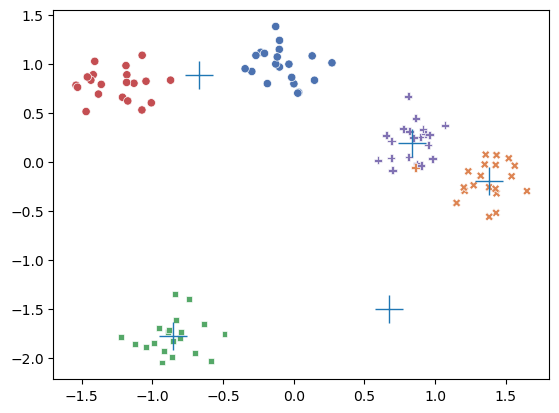

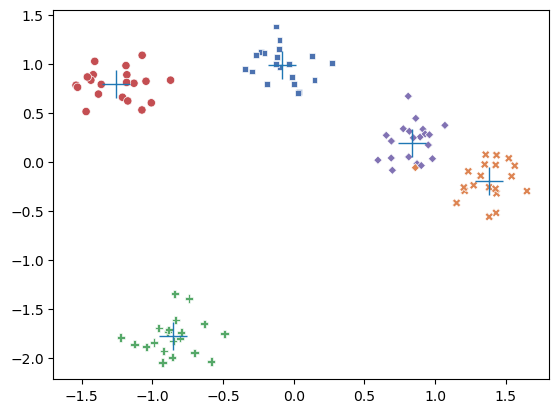

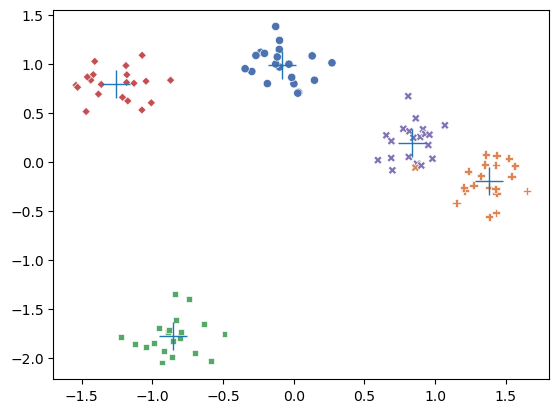

In [4]:
import warnings
warnings.filterwarnings('ignore')


for i in range(3):
    kmeans = KMeans(n_clusters=centers) # Передадим количество кластеров, которое мы задали в данных
    kmeans.fit(X_train)
    # View results
    class_centers, classification = kmeans.evaluate(X_train)
    sns.scatterplot(x=[X[0] for X in X_train],
                    y=[X[1] for X in X_train],
                    hue=true_labels,
                    style=classification,
                    palette="deep",
                    legend=None
                    )
    plt.plot([x for x, _ in kmeans.centroids],
            [y for _, y in kmeans.centroids],
            '+',
            markersize=20,
            )
    plt.show()

**Задание**

Ответьте на вопросы:
* Почему при каждом новом запуске у нас получались разные разбиения на кластеры?
* Оцените работу вашей реализации. С чем связаны плохие результаты? (это нормально, они и должны быть такими)
* При каких стартовых значениях центройдов алгоритм может работать плохо?

### Ответы:

- Мы получали разные разбиения на кластеры из-за того, что алгоритм выбирал различные центроиды при каждом запуске программы, а от них зависит наше конечное разбиение. Точки могут вообще никуда не двигаться из-за позиции или двигаться в неправильном направлении и тд. И если алгоритм ограничен различным количеством итераций, то от него тоже зависит ход исполнения программы

- Работа этой реализации работает так себе, неправильно классифицируют группы.
У нас есть три проблемы:
1. один центроид забирает себе две группы
2. центроид стоит в пустоте не забирая ни одну точку.
3. два центроида на одну группу

Проблема програмы связаны с тем что:
- алгоритм смещает центроид из-за выбросов, это может вызывать проблему _1_
- алгоритм задает случайная стартовая точки для центроидов, это может вызывать проблему _2_
- алгоритм позволяет найти хорошее значение, но только локально, при этом разбиение по всем данных будет плохое, может вызывать проблемы _2_, _3_

Как я понял, при следующих стартовых значениях центроидов, алгоритм работает плохо: 

1. Если два центроида появились в одном месте, то они маловероятно что разойдутся
наверное это происходит из-за того что они оба забрали вполне нормальный кластер, но алгоритм не обрабатывает это

2. Если какой-либо центроид появился вдали от какой-либо группы, то он не будет никуда двигаться
глупенький алгоритм, центроид находится слишком далеко от всех точек чтобы алгоритму понять куда двигаться

### Работа над ошибками

**Задание**

Поменяйте строчки инициализации центройдов с
```python
min_ = (np.min(X_train[:, 0]), np.min(X_train[:, 1]))
max_ = (np.max(X_train[:, 0]), np.max(X_train[:, 1]))
self.centroids = [uniform(min_, max_) for _ in range(self.n_clusters)]
```

на

```python
self.centroids = [random.choice(X_train)]
for _ in range(self.n_clusters-1):
    dists = np.sum([euclidean(centroid, X_train) for centroid in self.centroids], axis=0)
    dists /= np.sum(dists)
    new_centroid_idx, = np.random.choice(range(len(X_train)), size=1, p=dists)
    self.centroids += [X_train[new_centroid_idx]]
```


* Протестируйте ниже как работает ваш код с этим исправлением на тех же данных
* Объясните, что происходит в данном куске кода и почему это положительно влияет на результат

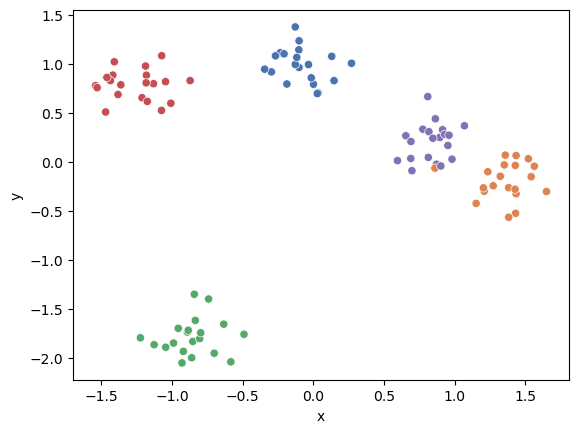

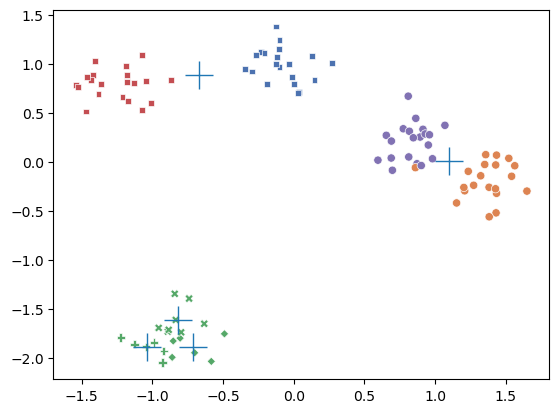

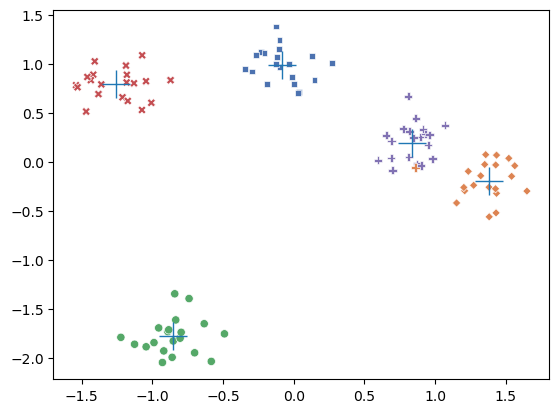

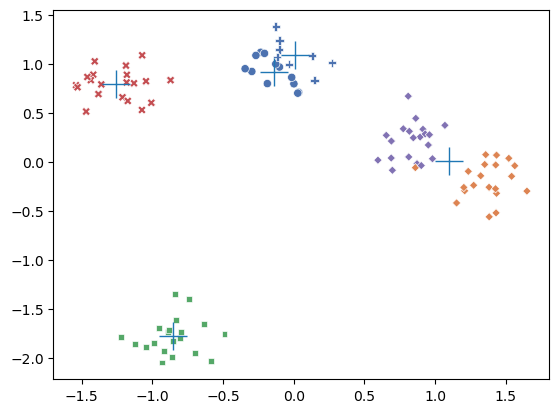

In [5]:
import seaborn as sns
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import warnings
warnings.filterwarnings('ignore')


centers = 5 # количество групп
X_train, true_labels = make_blobs(n_samples=100, centers=centers, random_state=42)
X_train = StandardScaler().fit_transform(X_train)
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=true_labels,
                palette="deep",
                legend=None
                )
plt.xlabel("x")
plt.ylabel("y")
plt.show()

def euclidean(point, data):
    """
    Euclidean distance between point & data.
    Point has dimensions (m,), data has dimensions (n,m), and output will be of size (n,).
    """
    # Все вычисления должны быть выполенны с помощью numpy без использования циклов
    result = np.sqrt(np.sum(np.power((data - point), 2), axis=1))
    return result

class KMeans:
    def __init__(self, n_clusters=8, max_iter=300):
        self.n_clusters = n_clusters # Количество кластеров
        self.max_iter = max_iter # Максимальное количество итераций

    def fit(self, X_train):
        """
        X_train: numpy array of shape (n,m)
        """
        # Случайно выбираем начальные точки центроида, равномерно распределенные по области набора данных

        #заменено
        #берем случайную точку из данных
        self.centroids = [random.choice(X_train)]

        #проходим циклом через все количество кластеров
        for _ in range(self.n_clusters-1):
            #считаем расстояние от каждого центроида до каждой точки в датасете
            dists = np.sum([euclidean(centroid, X_train) for centroid in self.centroids], axis=0)
            
            #делим расстояния на всю их сумму, чтобы получить вероятность
            #нам это нужно чтобы выбрать следующие центроиды
            dists /= np.sum(dists)

            #выбираем центроиды среди всех точек, случайным образом, но применяем полученный массив вероятностей для каждой точки
            new_centroid_idx, = np.random.choice(range(len(X_train)), size=1, p=dists)
            
            self.centroids += [X_train[new_centroid_idx]]

        # Итеративно повторяем до сходимости или до максимального количества итераций
        iteration = 0
        prev_centroids = None
        while np.not_equal(self.centroids, prev_centroids).any() and iteration < self.max_iter:

            # Сортируем точки по ближайшему центроиду
            sorted_points = [[] for _ in range(self.n_clusters)]
            for x in X_train:
                dists = euclidean(x, self.centroids)
                #Найдите индекс ближайшего центроида см. функцию np.argmin
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)

            # Сохраните текущие центроиды в prev_centroids
            prev_centroids = self.centroids
            # Обновите центроиды средним значением точек в кластере
            tmp = []
            for i in sorted_points:
                tmp.append(np.mean(i, axis=0))
            self.centroids = tmp

            for i, centroid in enumerate(self.centroids):
                if np.isnan(centroid).any():  # Если центроид не имеет ни одной точки, то выбираем предыдущее значение
                    self.centroids[i] = prev_centroids[i]
            iteration += 1

    def evaluate(self, X):
        """
        Function to evaluate the model on the dataset X.
        X: numpy array of shape (n,m)
        """
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)
        return centroids, centroid_idxs
    
for i in range(3):
    kmeans = KMeans(n_clusters=centers) # Передадим количество кластеров, которое мы задали в данных
    kmeans.fit(X_train)
    # View results
    class_centers, classification = kmeans.evaluate(X_train)
    sns.scatterplot(x=[X[0] for X in X_train],
                    y=[X[1] for X in X_train],
                    hue=true_labels,
                    style=classification,
                    palette="deep",
                    legend=None
                    )
    plt.plot([x for x, _ in kmeans.centroids],
            [y for _, y in kmeans.centroids],
            '+',
            markersize=20,
            )
    plt.show()

1. выбор стартовой позиции
    - раннее мы выбирали либо максимум либо минимум по всем точкам, из-за этой стартовой позиции точки могли просто никуда не двигаться
    - а сейчас мы этого избегаем за счет того что берем случаную существующую точку из данных
2. движение центроидов
    - мы выбираем следующий центроид за счет вычисление среднего всех точек в предполагаемом кластере, что не всегда круто, центроид может застрять не там где надо или два центроида будут в одном место
    - сначала мы считаем какие точки находятся дальше всего от текущих центроидов, и чем дальше тем больше будет вероятность что точка станет следующим центроидом, это круто потому что мы имеем возможность выбираться из не самых лучших ситуаций и сможем учитывать какие-то кластеры которых потеряли центроиды


## Кластеризация потребителей и интерпретируемость результатов (2 балла)

В данном задании мы воспользуемся уже готвой реализацией [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) из библиотеки sklearn. **НЕ НУЖНО ИСПОЛЬЗОВАТЬ СВОЮ**

В этой части мы будем использовать набор данных [The Airlines Customer Satisfaction](https://www.kaggle.com/datasets/sjleshrac/airlines-customer-satisfaction), который содержит информацию об удовлетворенности клиентов авиакомпании. Каждая запись представляет клиента, а переменные включают в себя демографические данные клиента, тип поездки (бизнес и т. д.) и оценки удовлетворенности различными аспектами полета.

Посмотрим на данные

In [6]:
import pandas as pd

airline_data = pd.read_csv('airline.csv')
airline_data.head(5)

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


### Препроцессинг

Давайте удалим некоторые столбцы, которые мы не хотим влиять на наши кластеры - для этого я удалю все категориальные столбцы из возможного решения:

* Satisfaction;
* Gender;
* Customer Type;
* Class;
* Type of Travel;

Когда речь идет о категориальных переменных, мы не хотим иметь слишком много фиктивных переменных, влияющих на наши кластеры.
По мере добавления в решение k-means все большего количества бинарных (также называемых фиктивными) переменных, эти переменные начинают иметь большой вес в итоговых расстояниях кластеризации, даже после стандартизации, поэтому очень важно быть осторожным при добавлении этих типов данных в любое решение k-means.

**Задание** Удалите с помощью функции `.drop` эти переменные из датасета

In [7]:
airline_data_filter = airline_data.drop(["Gender", "satisfaction", "Customer Type", "Class", "Type of Travel"], axis="columns")
airline_data_filter

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,65,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,47,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,15,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,60,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,70,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,29,1731,5,5,5,3,2,5,2,2,3,3,4,4,4,2,0,0.0
129876,63,2087,2,3,2,4,2,1,1,3,2,3,3,1,2,1,174,172.0
129877,69,2320,3,0,3,3,3,2,2,4,4,3,4,2,3,2,155,163.0
129878,66,2450,3,2,3,2,3,2,2,3,3,2,3,2,1,2,193,205.0


Также у нас есть пропуски в "Arrival Delay in Minutes" давайте заполним их

In [8]:
import numpy as np
'''ad = airline_data_filter['Arrival Delay in Minutes']
print(np.sum(ad.isna()))
print(np.sum(ad.notna()))
print(np.sum(ad.isna()) / (np.sum(ad.isna()) + np.sum(ad.notna())))'''

airline_data_filter['Arrival Delay in Minutes'] = np.where(
    airline_data_filter['Arrival Delay in Minutes'].isna(),
    airline_data_filter['Departure Delay in Minutes'],
    airline_data_filter['Arrival Delay in Minutes']
)

**Задание** В дальнейшем нам тяжело будет анализировать результаты кластеризации из-за очень большой размерности наших векторов-признаков. Более того высокая размерность часто плохо сказывается на алгоритме K-Means.

Для того чтоб избавиться от некоторых признаков можно воспользоваться уже знакомым некоторым приёмом - удалить или скомбинировать высокоскореллированные признаки.

Для этого постройте heatmap для корреляций признаков.

*Hint*: `pd.corr()` и `sns.heatmap` вам в помощь

<AxesSubplot: >

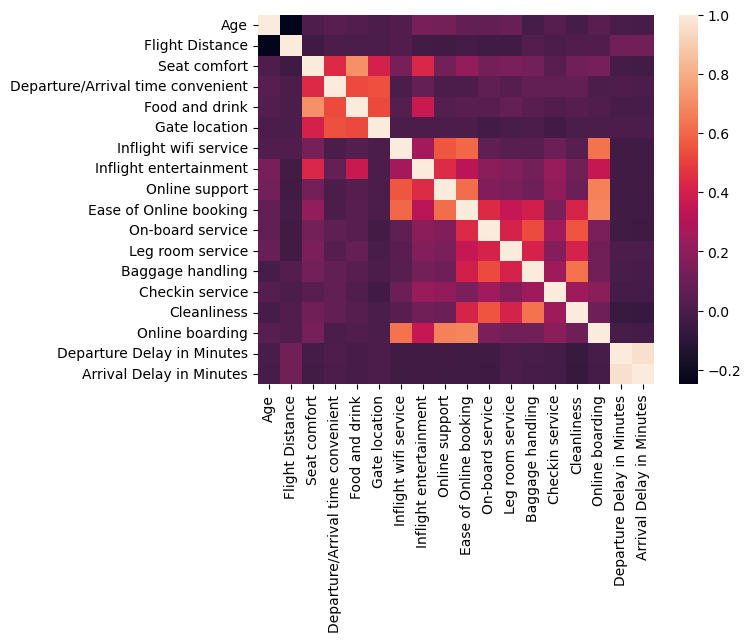

In [9]:
# Строим тепловую карту корреляции признаков
import seaborn as sns

correlation = airline_data_filter.corr()
sns.heatmap(correlation)

In [10]:
for i in list(airline_data_filter):
    print(i)

Age
Flight Distance
Seat comfort
Departure/Arrival time convenient
Food and drink
Gate location
Inflight wifi service
Inflight entertainment
Online support
Ease of Online booking
On-board service
Leg room service
Baggage handling
Checkin service
Cleanliness
Online boarding
Departure Delay in Minutes
Arrival Delay in Minutes


**Задание** А теперь возьмите среднее из групп признаков, которые имеют между собой высокую коррелцию.

Создайте новые признаки:
* Online and Wi-Fi Satisfaction - среднее из 'Online boarding', 'Inflight wifi service', 'Online support', 'Ease of Online booking'
* Comfort & Food - среднее из 'Seat comfort', 'Food and drink'

(не забудьте удалить признаки, которые использовали в новых переменных, чтоб они не дублировались)

In [11]:
airline_data_filter["Online and Wi-Fi Satisfaction"] = np.mean(airline_data_filter[["Online boarding", "Inflight wifi service", "Online support", "Ease of Online booking"]], axis=1)
airline_data_filter["Comfort & Food"] = np.mean(airline_data_filter[["Seat comfort", "Food and drink"]], axis=1)
airline_data_filter = airline_data_filter.drop(["Online boarding", "Inflight wifi service", "Online support", "Ease of Online booking", "Seat comfort", "Food and drink"], axis="columns")

In [12]:
airline_data_filter

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Online and Wi-Fi Satisfaction,Comfort & Food
0,65,265,0,2,4,3,0,3,5,3,0,0.0,2.25,0.0
1,47,2464,0,3,2,4,4,4,2,3,310,305.0,1.75,0.0
2,15,2138,0,3,0,3,3,4,4,4,0,0.0,2.00,0.0
3,60,623,0,3,4,1,0,1,4,1,0,0.0,2.50,0.0
4,70,354,0,3,3,2,0,2,4,2,0,0.0,3.75,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,29,1731,5,3,5,3,3,4,4,4,0,0.0,2.00,5.0
129876,63,2087,3,4,1,2,3,3,1,2,174,172.0,1.75,2.0
129877,69,2320,0,3,2,4,3,4,2,3,155,163.0,2.75,3.0
129878,66,2450,2,2,2,3,2,3,2,1,193,205.0,2.50,3.0


Следующий шаг в предобработке данных - стандартизация, нам нужно добиться чтоб разные признаки имели одинаковый масштаб, то есть значения всех переменных были в промежутке от 0 до 1.

Этого можно добиться использовав [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) из библиотеки sklearn.

**Задание**  Объясните своми словами, почему важна стандартизация в алгоритме K-Means.

Стандартизация в алгоритме K-means необходима, тк нам необходимо чтобы все признаки имели одинаковое влияние на модель.
Чтобы не перевешивал какой-то конкретный признак, ломая нам всю модель.

**Задание**  Воспользуйтесь StandardScaler

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
scaled_airline = standard_scaler.fit_transform(airline_data_filter)
scaled = minmax_scaler.fit_transform(scaled_airline)
scaled

array([[0.74358974, 0.03115491, 0.        , ..., 0.        , 0.38888889,
        0.        ],
       [0.51282051, 0.34980438, 0.        , ..., 0.19255051, 0.27777778,
        0.        ],
       [0.1025641 , 0.30256485, 0.        , ..., 0.        , 0.33333333,
        0.        ],
       ...,
       [0.79487179, 0.32893784, 0.        , ..., 0.10290404, 0.5       ,
        0.6       ],
       [0.75641026, 0.34777568, 0.4       , ..., 0.12941919, 0.44444444,
        0.6       ],
       [0.3974359 , 0.61686712, 0.8       , ..., 0.11742424, 0.61111111,
        0.6       ]])

Ура! Вы сделали это! Теперь мы можем применить наш алгоритм к нашим данным!

### K-means

Давайте обучим модель KMeans на наших данных и посмотрим, как она разделит наши данные на кластеры.


Но для начала нам нужно определить, какое количество кластеров мы хотим использовать. Для этого мы будем использовать elbow method. \
Этот метод заключается в том, чтобы построить график, показывающий, как $J^{class}$ изменяется в зависимости от количества кластеров и посмотреть при каком количестве класетров виден перегиб в скорости уменьшения падения графика.

**Задание** Переберите размеры кластеров от 2 до 12, обучите K-Means при каждом размере кластера и постройте график демонстрирующий изменение метрики.

*Hint*: Внимательно прочитавший документацию к K-Means в sklearn уже знает, что эта метрика хранится в переменнной `inertia_` после обучения.

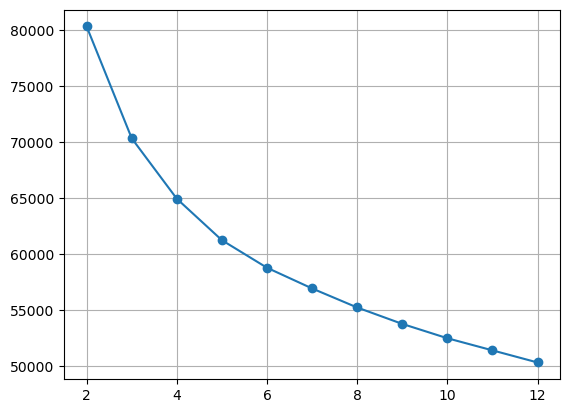

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

all_inertia = []

for k in range(2, 13):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled)
    all_inertia.append(kmeans.inertia_)

plt.plot(range(2, 13), all_inertia, marker='o')
plt.grid()
plt.show()

**Задание** Объясните своими словами для чего нам необходимо использовать elbow method и какое количество вы выбрали (и почему). Почему мы не можем просто выбрать какое-то маленькое или какое-то большое количество кластеров?

Elbow method нам необходим для того чтобы найти точку перегиба в приросте качества и выбрать наилучшее значение k, такое чтобы модель и не переобучилась и не недоучилась.
Elbow method нужен для того чтобы модель не была слишком сложной и чтобы не была слишком обобщенной.

Мы не можем просто взять какое-то большое количество кластеров, тк модель может переобучиться и будет подстраиваться под данные слишком точно, учитывая не нужные нам выбросы и шум. В этой модели будет мало полезного.

Так же мы не можем взять какое-то маленькое количество кластеров, потому что мы просто потеряем важные данные и не сможем толком ничего проанализировать.

**Задание** Теперь когда мы определилиcь с количеством класетров давайте обучим нашу модель и получим предсказание.

In [15]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(scaled)

airline_data_filter['cluster_kmeans'] = kmeans.predict(scaled_airline)
airline_data_filter['cluster_kmeans']

0         2
1         2
2         2
3         2
4         2
         ..
129875    2
129876    2
129877    2
129878    2
129879    2
Name: cluster_kmeans, Length: 129880, dtype: int32

### Анализируем результаты кластеризации

Тепреь когда мы кластеризовали наши данные пора посмотреть на какие кластеры он их распределил. Эта информация поможет нам понять основные группы наших клиентов и волнующие их проблемы.

Для этого сравним среднее значение признака по каждому кластеру с средним значением среди всех наших клиентов.

In [16]:
airline_data_filter.groupby(['cluster_kmeans']).mean()

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Online and Wi-Fi Satisfaction,Comfort & Food
cluster_kmeans,,,,,,,,,,,,,,
0,43.101854,1888.339604,4.626982,4.495745,4.366837,4.628415,4.544567,4.711189,4.008600,4.695064,11.820299,11.920362,4.090388,4.560512
1,41.661619,1938.631334,1.964609,1.949713,3.875726,4.467056,4.354544,4.580766,3.966229,4.557383,12.701764,12.890235,3.963922,2.100768
2,38.271612,2006.361371,3.110994,3.131577,3.107174,3.006267,3.081953,3.291884,3.061636,3.315733,15.703886,16.274170,3.135045,2.867388


In [17]:
airline_data_filter.mean()

Age                                    39.427957
Flight Distance                      1981.409055
Departure/Arrival time convenient       2.990645
Gate location                           2.990422
Inflight entertainment                  3.383477
On-board service                        3.465075
Leg room service                        3.485902
Baggage handling                        3.695673
Checkin service                         3.340807
Cleanliness                             3.705759
Departure Delay in Minutes             14.713713
Arrival Delay in Minutes               15.160102
Online and Wi-Fi Satisfaction           3.398381
Comfort & Food                          2.845296
cluster_kmeans                          1.609463
dtype: float64

In [18]:
airline_data_filter.groupby(['cluster_kmeans']).mean() - airline_data_filter.mean()

,Age,Arrival Delay in Minutes,Baggage handling,Checkin service,Cleanliness,Comfort & Food,Departure Delay in Minutes,Departure/Arrival time convenient,Flight Distance,Gate location,Inflight entertainment,Leg room service,On-board service,Online and Wi-Fi Satisfaction,cluster_kmeans
cluster_kmeans,,,,,,,,,,,,,,,
0,3.673898,-3.239740,1.015516,0.667793,0.989305,1.715217,-2.893413,1.636337,-93.069450,1.505323,0.983360,1.058665,1.163340,0.692007,NaN
1,2.233663,-2.269867,0.885093,0.625422,0.851624,-0.744528,-2.011948,-1.026036,-42.777720,-1.040709,0.492249,0.868642,1.001981,0.565541,NaN
2,-1.156345,1.114068,-0.403789,-0.279170,-0.390026,0.022093,0.990174,0.120349,24.952316,0.141155,-0.276303,-0.403949,-0.458809,-0.263336,NaN


**Задание** Опишите подробно ключевые особенности каждого из наших кластеров


я перезапускал несколько раз, поэтому что-то я высчитал слишком точно, например проценты, но в целом как есть

У меня получилось три группы, я ставил их в порядке какой у меня был в таблице, поэтому сейчас порядок сменился

- нулевая, им все очень даже нравится
- первая, им что-то не нравится, а что-то нравится 
- вторая, им не нравится почти всё


нулевая группа это позитив в чистом виде, им все нравится, значений удовлетворения меньше среднего нет
летают меньше всего, -4.5%, но не слишком сильное отклонение

первая группа больше средняя, по возрасту посередине, по полетам, чуть-чуть не нравится, больше нравится, 
но если нравится то не сильно

вторая группа это негативные какие-то люди, почти все не нравится, 
но летают больше всего, правда на ~2%, но это больше чем первая на 3.5% и больше чем первая на ~6%
возможен накопительный эффект

**Задание** Предложите идеи, как повысить оценки для каждой из групп пользователей.

Хорошей идеей могут быть персонифицированные предложения: помните, что мы хотим сэкономить деньги компании, поэтому не раздавайте скидки тем, кому они не нужны.

Жаль, что нельзя сделать такие персонифицированные предложения что кому не нравится тому и даем скидку, поэтому есть два варинта:
- те, кто больше летают получают бонусы/скидки на следующие полеты, 
    * это позволит поощрять постоянных клиентов и удерживать тех кто сомневается
    * а так же позволит дать второй группе скидку, тк я думаю чем больше люди летают тем больше проблем замечают и проиходит неприятностей по типу задержек
    * плюс это базовый прием, есть всякие приколы по типу бонусной программы "мили" и тд
- давать бонусы тем у кого происходят задержки
    * это позволит снизить недовольство связанное с задержками и добавить косвенную причину выбрать эту компанию в следующий раз

# Свободное плавание

**Это задание на творческую оценку**


**Ученик, сделавший лучшее задание, получит автоматом 5 за следующую констатирующую работу**

Студент Даня — заядлый путешественник, мечтающий посетить как можно больше городов этим летом. Но у него есть одна особенность: Даня крайне разборчив в климате. Если во время поездки температура окажется для него слишком холодной или, наоборот, слишком жаркой — он будет расстроен. Сам Даня не может точно описать, какая погода ему нравится, но может указать один город, в котором ему идеальная летняя температура.

Ваша цель — помочь Дане выбрать города с комфортным для него климатом, используя метод k-means для кластеризации. Мы постараемся разделить города на кластеры с похожими климатическими условиями, чтобы создать список мест, в которых Дане было бы приятно провести лето.

*Условия задачи*

1. Климатическая однородность: В каждом кластере города должны быть максимально близки по погодным условиям, чтобы Даня не столкнулся с сюрпризами в климате.
2. Размер кластеров: Каждый кластер должен включать достаточное количество городов, чтобы Даня мог выбрать и построить насыщенный маршрут.

В данном задании предлагается пользоваться датасетом [World Weather Repository](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository). В нем описаны исторические данные о погоде в городах за последние 5 месяцев для каждого из дней (около 40 различных признаков). Вам необходимо кластеризовать эти города по погоде.

(ладно не совсем свободное плавание)  
План решения задачи:
1. Предобработка данных
    1. Фильтрация записей: Оставьте только записи, относящиеся к летнему периоду (июнь, июль, август).
    2. Отбор признаков: Вам не обязательно использовать все признаки. Подумайте и выберите только те признаки которые могут быть полезны, например `temperature_fahrenheit` будет бесполезна, если вы уже используете `temperature_celsius`.
    3. Агрегация данных по городу: Объедините исторические записи о каждом городе.  Например, для численных признаков по типу температуры можно взять минимум, максимум и среднюю температуру.
    4. Стандартизация признаков: Преобразуйте данные, чтобы все признаки находились примерно в одном масштабе. Это сделает кластеризацию более точной.
2. K-Means
    1. Определение оптимального количества кластеров: Используйте метод локтя (Elbow Method), чтобы определить оптимальное значение параметра k (количество кластеров).
    2. Обучение модели: Примените k-means с выбранным значением k и обучите модель.
    3. Анализ кластеров: Проанализируйте результаты вашего алгоритма, при необходимости поменяйте количество кластеров
3. Визуализация результатов, изобразите на карте разбиение городов по климату. В этом пункте вы вольны делать что хотите, поэкспериментируйте с разными вариантами графиков.

Полезные ресурсы для вдохновления:
* [Основы работы с folium](https://medium.com/@enduranceprog/creating-a-python-web-map-5d5a5c081078)
* [Подробно про работу с геоданными в Python и Jupyter](https://proglib.io/p/rabota-s-geodannymi-v-python-i-jupyter-2021-03-22)
* [ Десять простых примеров использования folium](https://snyk.io/advisor/python/folium/example)
